In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Ustawienie stylu i czcionek
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Biblioteki zaimportowane pomyślnie")

Biblioteki zaimportowane pomyślnie


In [31]:
# Wczytanie danych
df = pd.read_csv('data\\XWines_Slim_150K_ratings.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Dodatkowe kolumny czasowe
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Year'] = df['Date'].dt.year

# Mapowanie na polskie nazwy
day_mapping = {
    'Monday': 'Poniedziałek',
    'Tuesday': 'Wtorek', 
    'Wednesday': 'Środa',
    'Thursday': 'Czwartek',
    'Friday': 'Piątek',
    'Saturday': 'Sobota',
    'Sunday': 'Niedziela'
}
df['DayOfWeek_PL'] = df['DayOfWeek'].map(day_mapping)

print(f"Wczytano {len(df)} wierszy")
print(f"Zakres dat: {df['Date'].min()} do {df['Date'].max()}")
print(f"Liczba unikalnych użytkowników: {df['UserID'].nunique()}")
print(f"Liczba unikalnych win: {df['WineID'].nunique()}")

Wczytano 150000 wierszy
Zakres dat: 2012-04-19 20:46:00 do 2021-12-31 23:58:52
Liczba unikalnych użytkowników: 10561
Liczba unikalnych win: 1007


C:\Users\Filip\AppData\Local\Temp\ipykernel_7500\2908921142.py:2: DtypeWarning: Columns (0: Vintage) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data\\XWines_Slim_150K_ratings.csv')


## Statystyki do opisu w pracy (EDA)

In [32]:
print("=" * 60)
print("STATYSTYKI DO PRACY - ROZKŁAD OCEN")
print("=" * 60)

rating_dist = df["Rating"].value_counts(normalize=True).sort_index() * 100
for rating, pct in rating_dist.items():
    print(f"Ocena {rating}: {pct:.1f}%")

print(f"\nOceny 4 i 5 łącznie:     {rating_dist[4] + rating_dist[5]:.1f}%")
print(f"Oceny 1 i 2 łącznie:     {rating_dist[1] + rating_dist[2]:.1f}%")
print(f"Dominanta:               {df['Rating'].mode()[0]}")
print(f"Mediana:                 {df['Rating'].median()}")
print(f"Średnia:                 {df['Rating'].mean():.2f}")

print("\n" + "=" * 60)
print("STATYSTYKI - AKTYWNOŚĆ UŻYTKOWNIKÓW")
print("=" * 60)

user_counts = df.groupby("UserID")["Rating"].count()
print(f"Dominanta (najczęstsza liczba ocen): {user_counts.mode()[0]}")
print(f"Mediana liczby ocen:                 {user_counts.median():.1f}")
print(f"Średnia liczba ocen:                 {user_counts.mean():.1f}")
print(f"Max liczba ocen:                     {user_counts.max()}")
print(f"Min liczba ocen:                     {user_counts.min()}")
print(f"\nUżytkownicy z < 3 ocenami:  {(user_counts < 3).mean()*100:.1f}%")
print(f"Użytkownicy z < 5 ocenami:  {(user_counts < 5).mean()*100:.1f}%")
print(f"Użytkownicy z < 10 ocenami: {(user_counts < 10).mean()*100:.1f}%")

print("\n" + "=" * 60)
print("STATYSTYKI - POPULARNOŚĆ WIN")
print("=" * 60)

wine_counts = df.groupby("WineID")["Rating"].count()
print(f"Dominanta: {wine_counts.mode()[0]}")
print(f"Mediana:   {wine_counts.median():.1f}")
print(f"Średnia:   {wine_counts.mean():.1f}")
print(f"Max:       {wine_counts.max()}")
print(f"Min:       {wine_counts.min()}")

# Long tail
wine_counts_sorted = wine_counts.sort_values(ascending=False)
total = wine_counts_sorted.sum()
cumsum = wine_counts_sorted.cumsum()
wines_80 = (cumsum <= total * 0.80).sum()
pct_wines_80 = wines_80 / len(wine_counts_sorted) * 100
print(f"\nLiczba win odpowiadających za 80% ocen: {wines_80} ({pct_wines_80:.1f}% wszystkich win)")

print("\n" + "=" * 60)
print("STATYSTYKI - SEZONOWOŚĆ")
print("=" * 60)

monthly_counts = df.groupby('Month')['Rating'].count()
monthly_avg = df.groupby('Month')['Rating'].mean()
month_names = ['Sty', 'Lut', 'Mar', 'Kwi', 'Maj', 'Cze', 
               'Lip', 'Sie', 'Wrz', 'Paź', 'Lis', 'Gru']

print(f"Miesiąc z największą liczbą ocen: {month_names[monthly_counts.idxmax()-1]} ({monthly_counts.max()} ocen)")
print(f"Miesiąc z najmniejszą liczbą ocen: {month_names[monthly_counts.idxmin()-1]} ({monthly_counts.min()} ocen)")
print(f"\nMiesiąc z najwyższą średnią: {month_names[monthly_avg.idxmax()-1]} ({monthly_avg.max():.3f})")
print(f"Miesiąc z najniższą średnią: {month_names[monthly_avg.idxmin()-1]} ({monthly_avg.min():.3f})")
print(f"Rozstęp średnich miesięcznych: {monthly_avg.max() - monthly_avg.min():.3f}")

print("\n" + "=" * 60)
print("STATYSTYKI - DNI TYGODNIA")
print("=" * 60)

day_avg = df.groupby('DayOfWeek')['Rating'].mean()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_pl = ['Poniedziałek', 'Wtorek', 'Środa', 'Czwartek', 'Piątek', 'Sobota', 'Niedziela']

for eng, pl in zip(day_order, day_pl):
    print(f"{pl}: {day_avg[eng]:.3f}")

print(f"\nRozstęp między dniami: {day_avg.max() - day_avg.min():.3f}")

STATYSTYKI DO PRACY - ROZKŁAD OCEN
Ocena 1.0: 0.3%
Ocena 1.5: 0.2%
Ocena 2.0: 1.3%
Ocena 2.5: 2.6%
Ocena 3.0: 12.8%
Ocena 3.5: 24.3%
Ocena 4.0: 36.0%
Ocena 4.5: 14.7%
Ocena 5.0: 7.6%

Oceny 4 i 5 łącznie:     43.7%
Oceny 1 i 2 łącznie:     1.6%
Dominanta:               4.0
Mediana:                 4.0
Średnia:                 3.82

STATYSTYKI - AKTYWNOŚĆ UŻYTKOWNIKÓW
Dominanta (najczęstsza liczba ocen): 10
Mediana liczby ocen:                 12.0
Średnia liczba ocen:                 14.2
Max liczba ocen:                     67
Min liczba ocen:                     1

Użytkownicy z < 3 ocenami:  2.4%
Użytkownicy z < 5 ocenami:  2.9%
Użytkownicy z < 10 ocenami: 20.4%

STATYSTYKI - POPULARNOŚĆ WIN
Dominanta: 8
Mediana:   53.0
Średnia:   149.0
Max:       1540
Min:       1

Liczba win odpowiadających za 80% ocen: 276 (27.4% wszystkich win)

STATYSTYKI - SEZONOWOŚĆ
Miesiąc z największą liczbą ocen: Gru (15762 ocen)
Miesiąc z najmniejszą liczbą ocen: Lut (11064 ocen)

Miesiąc z najwyższą śred

## Wykresy EDA z polskimi podpisami

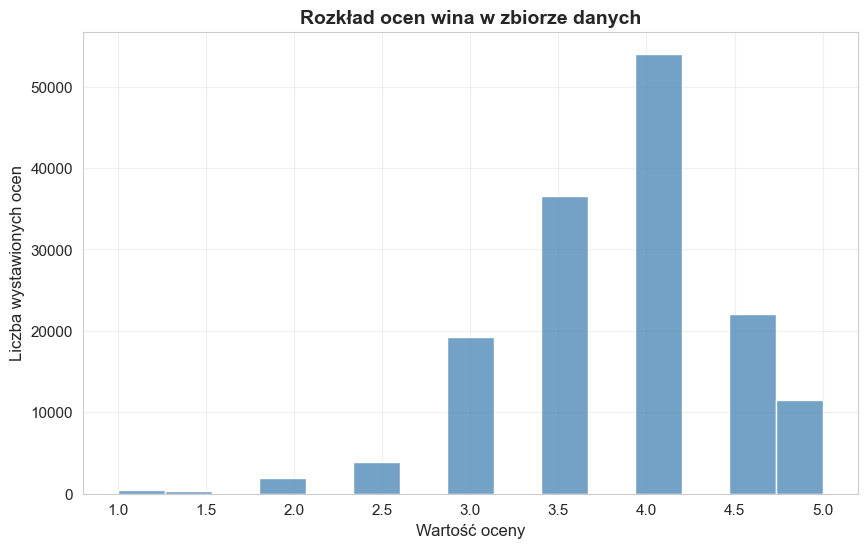

In [58]:
# WYKRES 1: Rozkład ocen
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'], bins=15, color='steelblue')
plt.xlabel("Wartość oceny", fontsize=12)
plt.ylabel("Liczba wystawionych ocen", fontsize=12)
plt.title("Rozkład ocen wina w zbiorze danych", fontsize=14, fontweight='bold')
plt.xticks([1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5])
plt.grid(True, alpha=0.3)

plt.show()

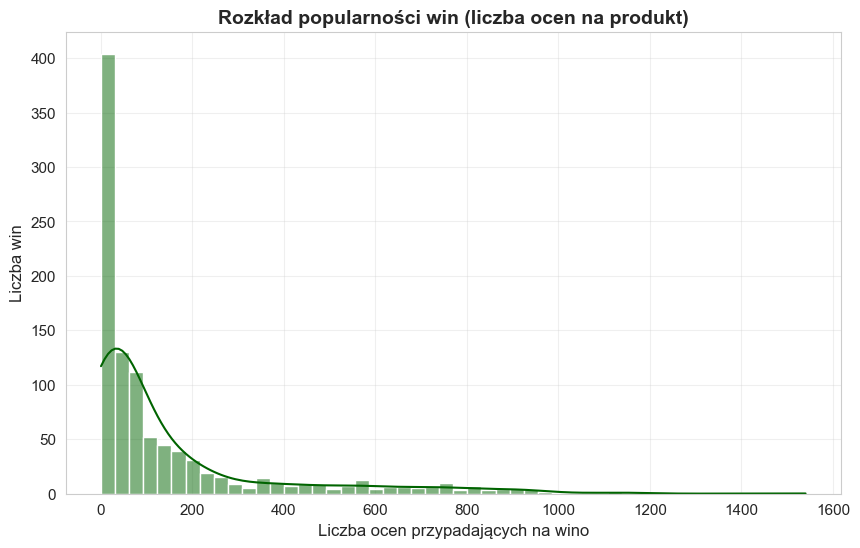

In [34]:
# WYKRES 2: Liczba ocen na wino (Long Tail)
plt.figure(figsize=(10, 6))
sns.histplot(df['WineID'].value_counts(), bins=50, kde=True, color='darkgreen')
plt.xlabel("Liczba ocen przypadających na wino", fontsize=12)
plt.ylabel("Liczba win", fontsize=12)
plt.title("Rozkład popularności win (liczba ocen na produkt)", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.show()

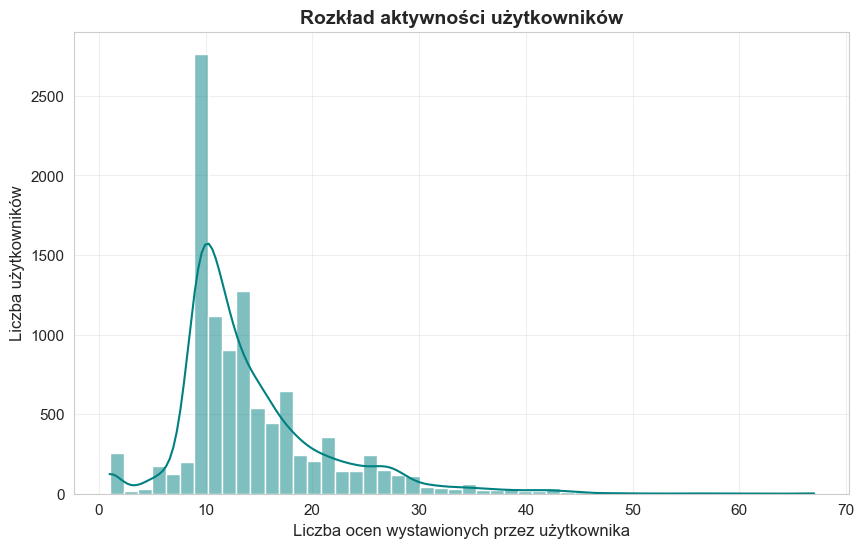

In [35]:
# WYKRES 3: Aktywność użytkowników
user_counts = df.groupby("UserID")["Rating"].count()

plt.figure(figsize=(10, 6))
sns.histplot(user_counts, bins=50, kde=True, color='teal')
plt.xlabel("Liczba ocen wystawionych przez użytkownika", fontsize=12)
plt.ylabel("Liczba użytkowników", fontsize=12)
plt.title("Rozkład aktywności użytkowników", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.show()

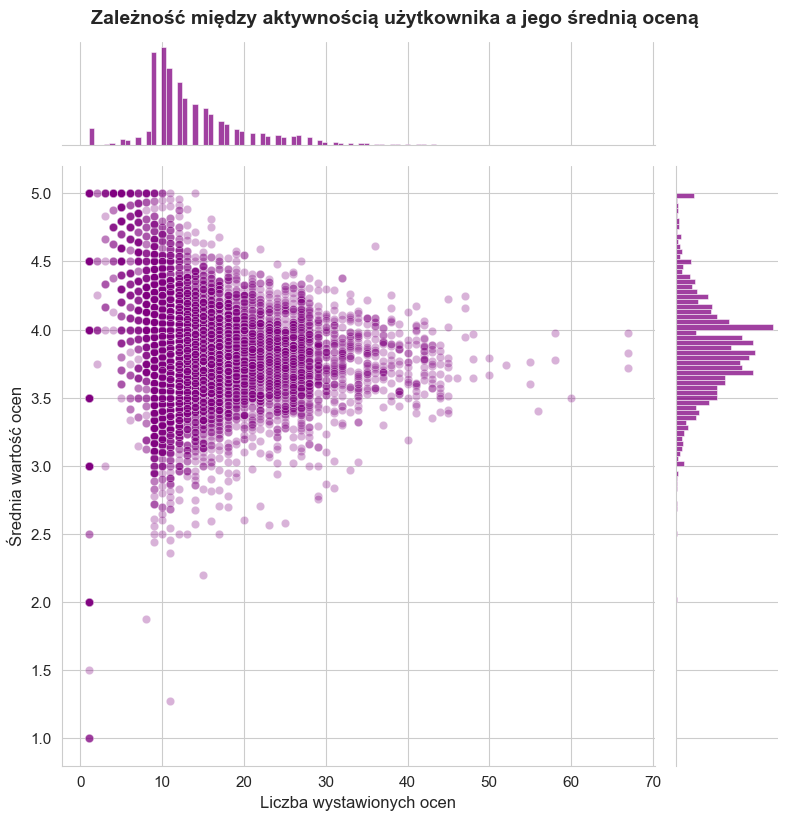

In [36]:
# WYKRES 4: Zależność liczba ocen vs średnia ocena (Joint Plot)
user_stats = df.groupby('UserID').agg({'Rating': ['count', 'mean']})

g = sns.jointplot(
    x=user_stats[('Rating', 'count')], 
    y=user_stats[('Rating', 'mean')], 
    alpha=0.3,
    color='purple',
    height=8
)
g.set_axis_labels("Liczba wystawionych ocen", "Średnia wartość ocen", fontsize=12)
g.fig.suptitle("Zależność między aktywnością użytkownika a jego średnią oceną", 
               y=1.02, fontsize=14, fontweight='bold')

plt.show()

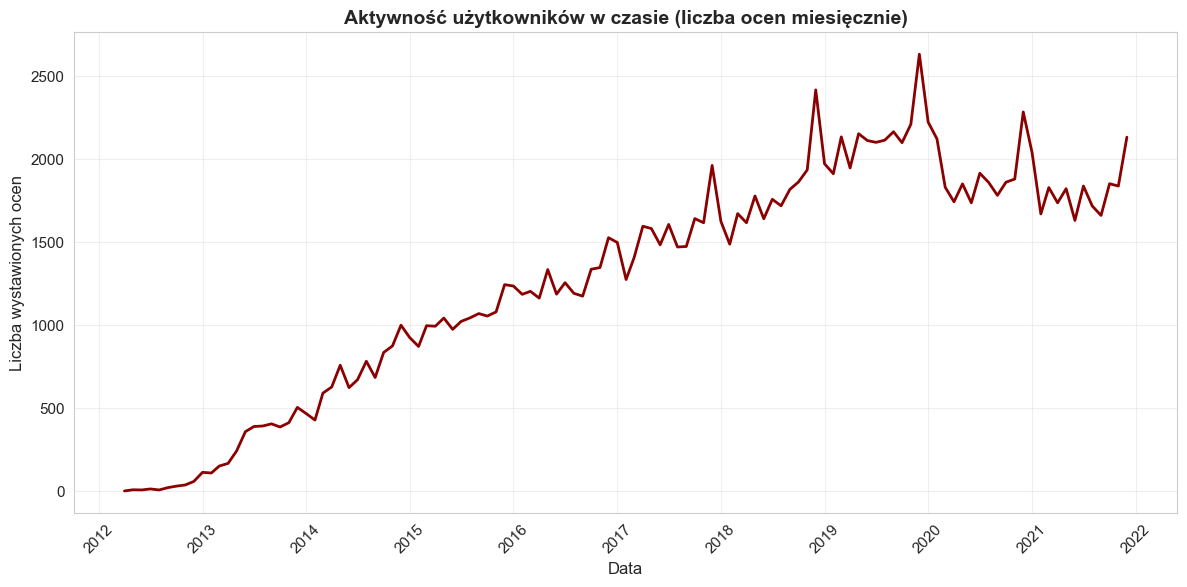

In [37]:
# WYKRES 5: Aktywność w czasie
ratings_over_time = df.groupby(df['Date'].dt.to_period('M')).size()

plt.figure(figsize=(12, 6))
sns.lineplot(
    x=ratings_over_time.index.to_timestamp(), 
    y=ratings_over_time.values,
    color='darkred',
    linewidth=2
)
plt.xlabel("Data", fontsize=12)
plt.ylabel("Liczba wystawionych ocen", fontsize=12)
plt.title("Aktywność użytkowników w czasie (liczba ocen miesięcznie)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

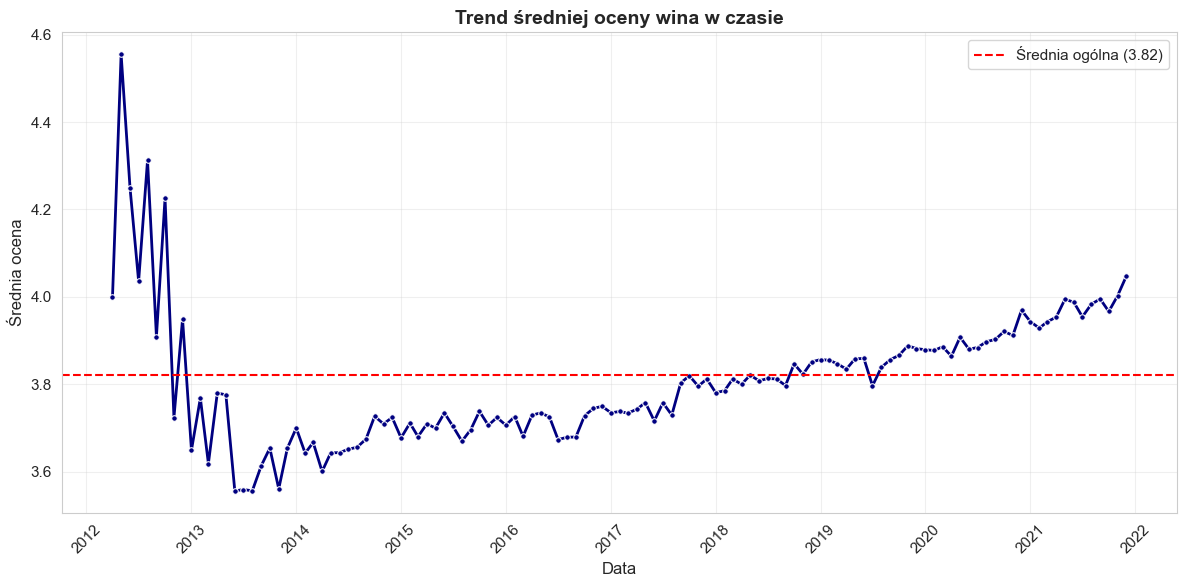

In [38]:
# WYKRES 6: Średnia ocena w czasie
monthly_avg_rating = df.groupby(df['Date'].dt.to_period('M'))['Rating'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(
    x=monthly_avg_rating.index.to_timestamp(),
    y=monthly_avg_rating.values,
    color='navy',
    linewidth=2,
    marker='o',
    markersize=4
)
plt.xlabel("Data", fontsize=12)
plt.ylabel("Średnia ocena", fontsize=12)
plt.title("Trend średniej oceny wina w czasie", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.axhline(y=df['Rating'].mean(), color='red', linestyle='--', 
            label=f'Średnia ogólna ({df["Rating"].mean():.2f})')
plt.legend()
plt.tight_layout()

plt.show()

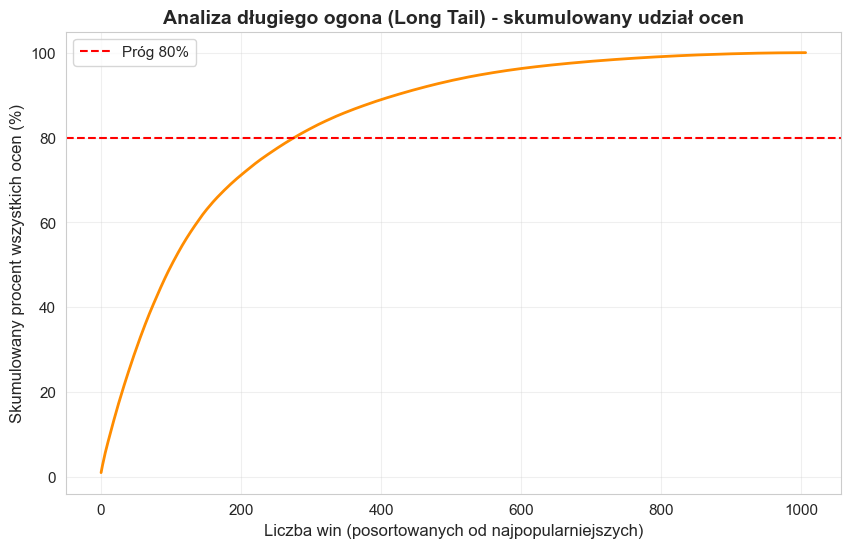

In [39]:
# WYKRES 7: Analiza Long Tail (skumulowany)
wine_counts = df.groupby('WineID').size().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(wine_counts)), 
         wine_counts.cumsum() / wine_counts.sum() * 100,
         color='darkorange',
         linewidth=2)
plt.axhline(y=80, color='red', linestyle='--', label='Próg 80%')
plt.title("Analiza długiego ogona (Long Tail) - skumulowany udział ocen", fontsize=14, fontweight='bold')
plt.xlabel("Liczba win (posortowanych od najpopularniejszych)", fontsize=12)
plt.ylabel("Skumulowany procent wszystkich ocen (%)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

C:\Users\Filip\AppData\Local\Temp\ipykernel_7500\194205284.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Month', palette='viridis')
C:\Users\Filip\AppData\Local\Temp\ipykernel_7500\194205284.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_names)


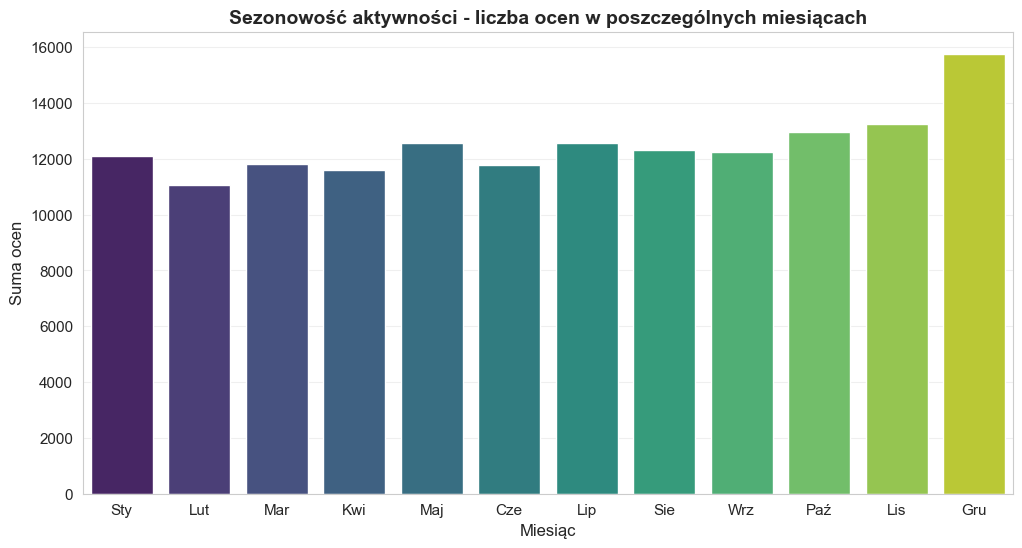

In [40]:
# WYKRES 8: Sezonowość - liczba ocen w miesiącach
month_names = ['Sty', 'Lut', 'Mar', 'Kwi', 'Maj', 'Cze', 
               'Lip', 'Sie', 'Wrz', 'Paź', 'Lis', 'Gru']

plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='Month', palette='viridis')
plt.title('Sezonowość aktywności - liczba ocen w poszczególnych miesiącach', fontsize=14, fontweight='bold')
plt.xlabel('Miesiąc', fontsize=12)
plt.ylabel('Suma ocen', fontsize=12)
ax.set_xticklabels(month_names)
plt.grid(True, alpha=0.3, axis='y')

plt.show()

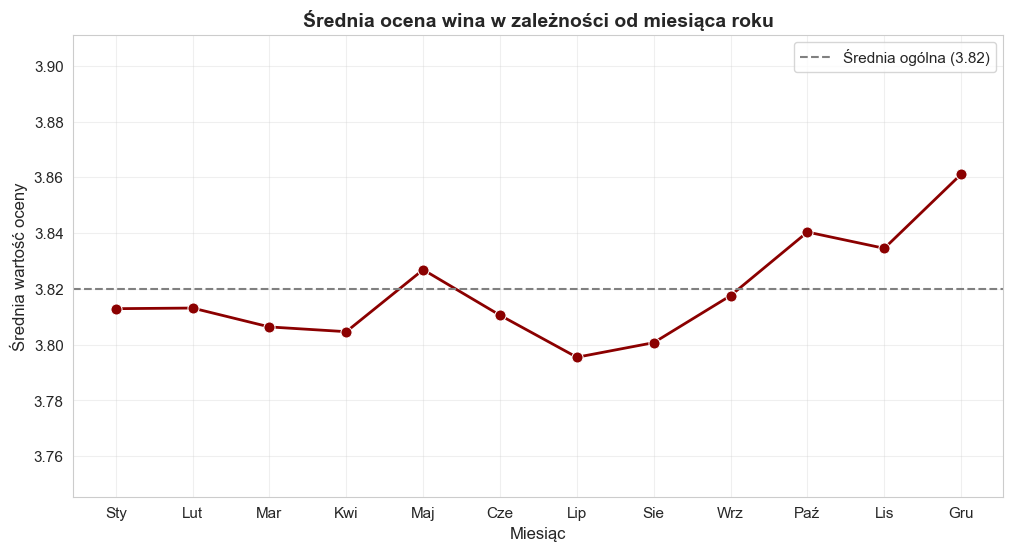

In [41]:
# WYKRES 9: Średnia ocena w zależności od miesiąca
monthly_avg = df.groupby('Month')['Rating'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, 
             marker='o', color='darkred', linewidth=2, markersize=8)
plt.axhline(y=df['Rating'].mean(), color='gray', linestyle='--', 
            label=f'Średnia ogólna ({df["Rating"].mean():.2f})')
plt.title('Średnia ocena wina w zależności od miesiąca roku', fontsize=14, fontweight='bold')
plt.xlabel('Miesiąc', fontsize=12)
plt.ylabel('Średnia wartość oceny', fontsize=12)
plt.xticks(np.arange(1, 13), month_names)
plt.ylim(monthly_avg.min() - 0.05, monthly_avg.max() + 0.05)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

C:\Users\Filip\AppData\Local\Temp\ipykernel_7500\2081963130.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='DayOfWeek_PL', y='Rating',


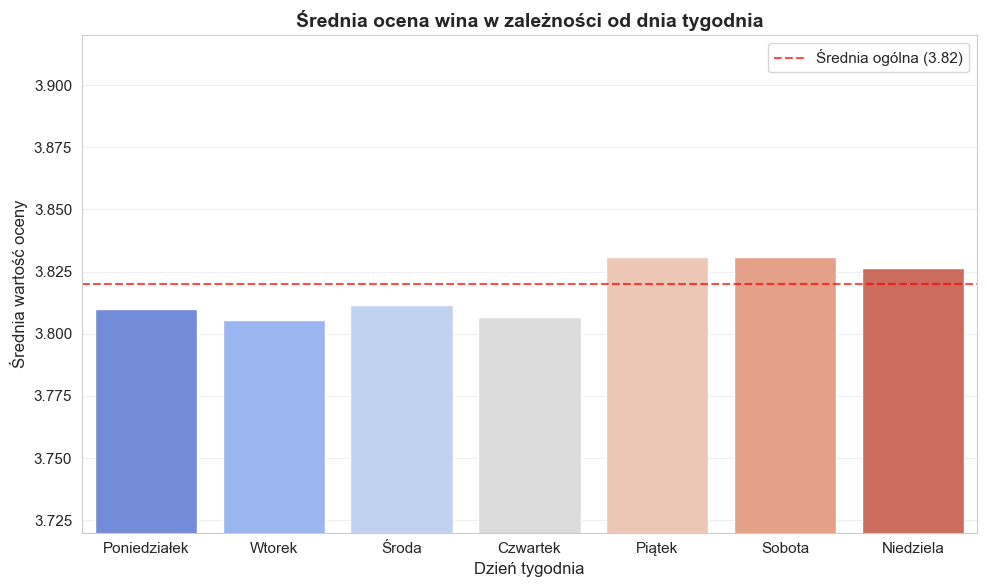

In [42]:
# WYKRES 10: Średnia ocena w zależności od dnia tygodnia
day_order = ['Poniedziałek', 'Wtorek', 'Środa', 'Czwartek', 
             'Piątek', 'Sobota', 'Niedziela']

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='DayOfWeek_PL', y='Rating', 
            order=day_order, palette='coolwarm', errorbar=None)
plt.title('Średnia ocena wina w zależności od dnia tygodnia', fontsize=14, fontweight='bold')
plt.xlabel('Dzień tygodnia', fontsize=12)
plt.ylabel('Średnia wartość oceny', fontsize=12)
plt.ylim(df['Rating'].mean() - 0.1, df['Rating'].mean() + 0.1)
plt.axhline(y=df['Rating'].mean(), color='red', linestyle='--', alpha=0.7,
            label=f'Średnia ogólna ({df["Rating"].mean():.2f})')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

plt.show()

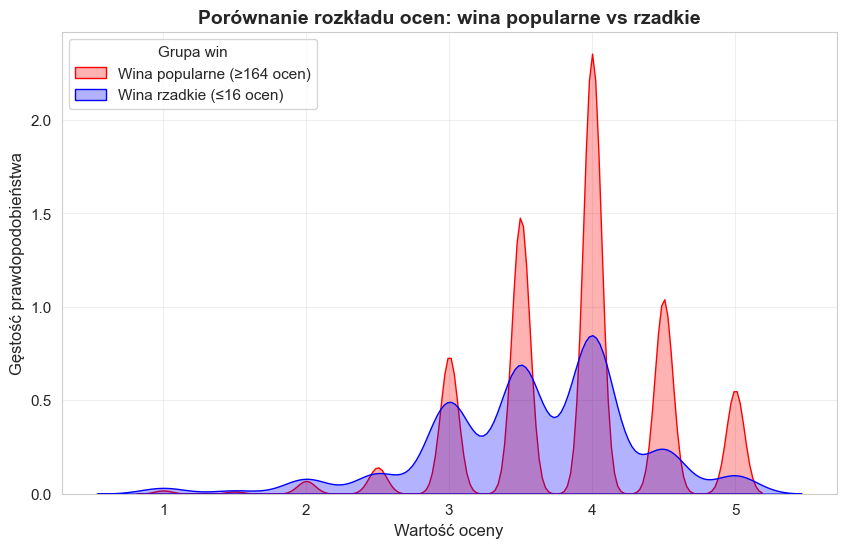

Średnia ocen win popularnych: 3.87
Średnia ocen win rzadkich: 3.59
Różnica: 0.28


In [43]:
# WYKRES 11: Porównanie popularne vs rzadkie wina (Bonus)
wine_popularity = df.groupby('WineID')['Rating'].count()
top_25_threshold = wine_popularity.quantile(0.75)
bottom_25_threshold = wine_popularity.quantile(0.25)

popular_wines = df[df['WineID'].isin(
    wine_popularity[wine_popularity >= top_25_threshold].index)]['Rating']
unpopular_wines = df[df['WineID'].isin(
    wine_popularity[wine_popularity <= bottom_25_threshold].index)]['Rating']

plt.figure(figsize=(10, 6))
sns.kdeplot(popular_wines, label=f'Wina popularne (≥{top_25_threshold:.0f} ocen)', 
            color='red', fill=True, alpha=0.3)
sns.kdeplot(unpopular_wines, label=f'Wina rzadkie (≤{bottom_25_threshold:.0f} ocen)', 
            color='blue', fill=True, alpha=0.3)
plt.xlabel("Wartość oceny", fontsize=12)
plt.ylabel("Gęstość prawdopodobieństwa", fontsize=12)
plt.title("Porównanie rozkładu ocen: wina popularne vs rzadkie", fontsize=14, fontweight='bold')
plt.legend(title='Grupa win')
plt.grid(True, alpha=0.3)

plt.show()

print(f"Średnia ocen win popularnych: {popular_wines.mean():.2f}")
print(f"Średnia ocen win rzadkich: {unpopular_wines.mean():.2f}")
print(f"Różnica: {popular_wines.mean() - unpopular_wines.mean():.2f}")